# 🦎 Iguana Species Classification — Transfer Learning Assignment

In this notebook we will classify **7 species of iguana** using Transfer Learning.

The 7 classes are:
- Black_spiny_tailed_iguana
- Brown_anole
- Cuban_knight_anole
- Desert_iguana
- Green_anole
- Green_iguana
- Lesser_Antillean_iguana

**Strategy:** We use a pretrained EfficientNetV2S model (trained on ImageNet) as a **feature extractor** with frozen weights, and add our own classification head on top.

---
### 📁 Expected folder structure
```
data/
  train/
    Black_spiny_tailed_iguana/  *.jpg
    Brown_anole/                *.jpg
    ...
  test/
    1.jpg, 2.jpg, ...
  train.csv               <- filename + label (for verification)
  test.csv                <- id column only (what we need to predict)
  Classes_nummering.xlsx  <- maps class names to numeric IDs
saved_models/             <- trained model will be saved here
```

## Step 0 — Install dependencies & Imports & GPU check

In [53]:
import tensorflow as tf

print(f"TensorFlow versie: {tf.__version__}")
print(f"Aantal GPU's gevonden: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow versie: 2.21.0
Aantal GPU's gevonden: 0


In [54]:
# Install all required packages
# Run this cell once; you can skip it on subsequent runs if packages are already installed
!pip install tensorflow>=2.16 \
             numpy \
             pandas \
             matplotlib \
             scikit-learn \
             openpyxl \
             Pillow


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Preprocessing for EfficientNetV2S ────────────────────────────────────────────
preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input


print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.21.0
GPUs available     : []


## Step 1 — Configuration

All the hyper-parameters you might want to tweak are collected here.

In [ ]:
# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR         = Path("data")
TRAIN_DIR        = DATA_DIR / "train"
TEST_DIR         = DATA_DIR / "test"
TRAIN_CSV        = DATA_DIR / "train.csv"
TEST_CSV         = DATA_DIR / "test.csv"
CLASSES_XLSX     = DATA_DIR / "Classes_nummering.xlsx"

SAVED_MODELS_DIR = Path("saved_models")
SAVED_MODELS_DIR.mkdir(exist_ok=True)   # create the folder if it doesn't exist yet
MODEL_PATH       = SAVED_MODELS_DIR / "iguana_model.keras"
SUBMISSION_PATH  = SAVED_MODELS_DIR / "submission.csv"

# ── image & training settings ──────────────────────────────────────────────────
IMG_SIZE         = 300      # EfficientNetV2S expects >= 224
BATCH_SIZE       = 32
EPOCHS           = 15
LEARNING_RATE    = 1e-3
VALIDATION_SPLIT = 0.2
SEED             = 42

NUM_CLASSES      = 7

## Step 2 — Explore the data

In [57]:
# ── Read the class numbering ────────────────────────────────────────────────────
classes_df = pd.read_excel(CLASSES_XLSX)
print(classes_df)
print("\nColumns:", classes_df.columns.tolist())

   Class                 Unnamed: 1
0      0  Black_spiny_tailed_iguana
1      1                Brown_anole
2      2         Cuban_knight_anole
3      3              Desert_iguana
4      4                Green_anole
5      5               Green_iguana
6      6    Lesser_Antillean_iguana

Columns: ['Class', 'Unnamed: 1']


In [58]:
# ── Peek at the CSVs ────────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("train.csv shape:", train_df.shape)
print(train_df.head())
print("\ntest.csv shape:", test_df.shape)
print(test_df.head())

train.csv shape: (1334, 2)
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

test.csv shape: (326, 1)
   id
0   1
1   2
2   3
3   4
4   5


In [59]:
# ── Count images per class ──────────────────────────────────────────────────────
class_counts = {}
for class_dir in sorted(TRAIN_DIR.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png")))
        class_counts[class_dir.name] = count

print("Images per class:")
for cls, cnt in class_counts.items():
    print(f"  {cls:<40} {cnt}")
print(f"\nTotal training images: {sum(class_counts.values())}")

Images per class:
  Black_spiny_tailed_iguana                199
  Brown_anole                              193
  Cuban_knight_anole                       189
  Desert_iguana                            183
  Green_anole                              178
  Green_iguana                             196
  Lesser_Antillean_iguana                  196

Total training images: 1334


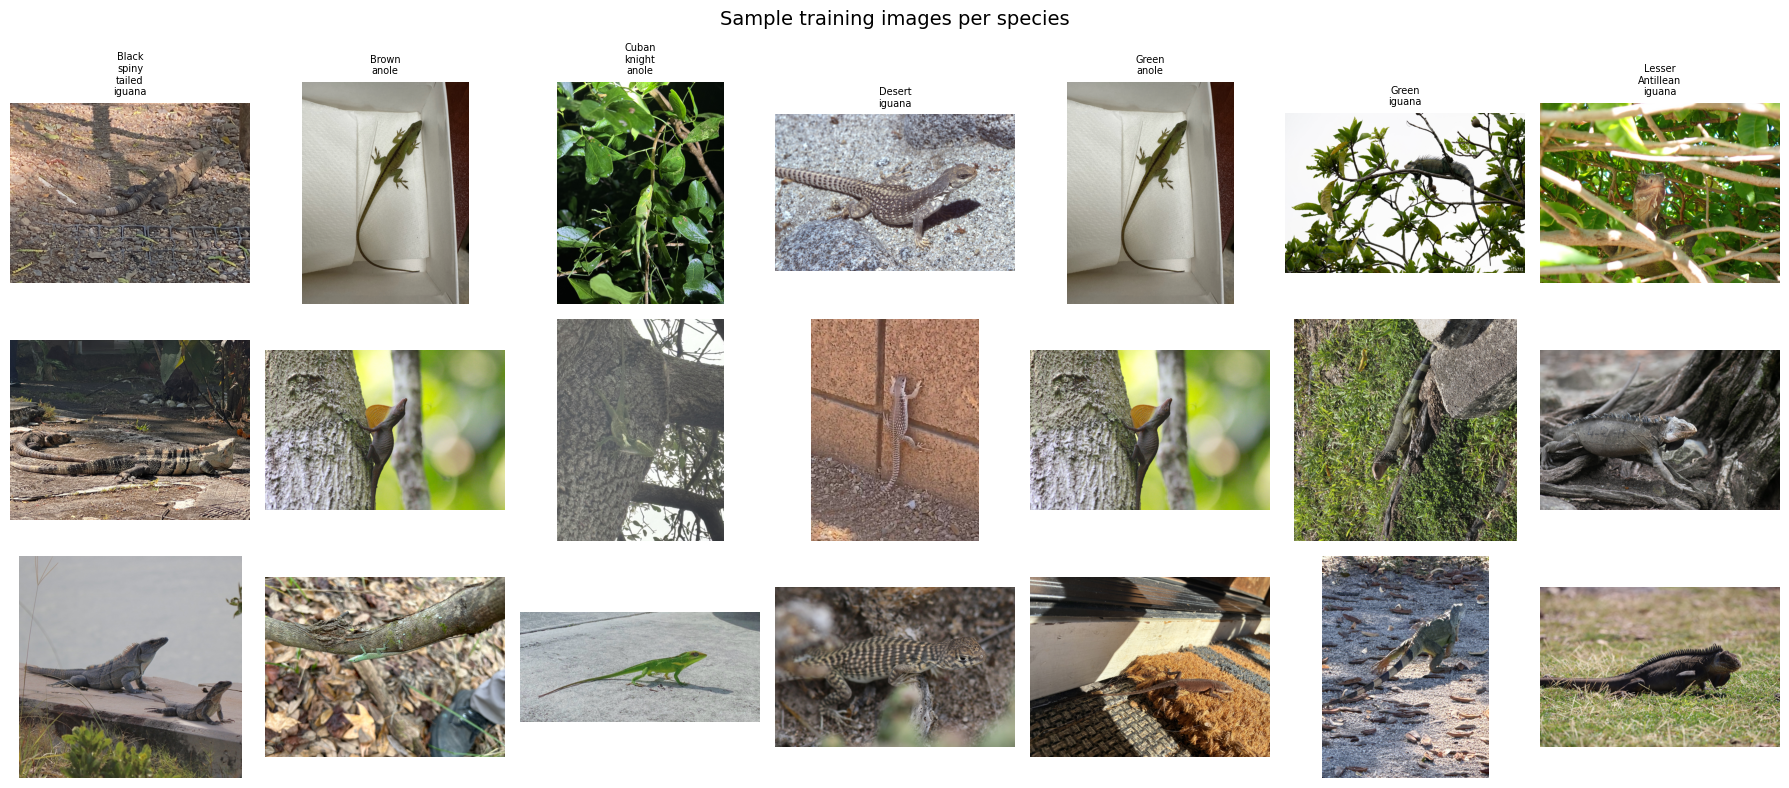

In [60]:
# ── Visualize a few training images ────────────────────────────────────────────
fig, axes = plt.subplots(3, 7, figsize=(18, 8))
class_names = sorted(class_counts.keys())

for col, cls in enumerate(class_names):
    images = list((TRAIN_DIR / cls).glob("*.jpg"))[:3]
    for row, img_path in enumerate(images):
        img = plt.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(cls.replace("_", "\n"), fontsize=7)

plt.suptitle("Sample training images per species", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — Build the data pipeline

We use `image_dataset_from_directory` which automatically infers class labels from the subfolder names. **No manual one-hot encoding needed!**

We also apply **data augmentation** to reduce overfitting.

In [61]:
# ── Training & validation datasets ─────────────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",   # one-hot encoded -> use categorical_crossentropy
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

# The class names as discovered by Keras (alphabetical order)
CLASS_NAMES = train_ds.class_names
print("Class names (in model order):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Class names (in model order):
  0: Black_spiny_tailed_iguana
  1: Brown_anole
  2: Cuban_knight_anole
  3: Desert_iguana
  4: Green_anole
  5: Green_iguana
  6: Lesser_Antillean_iguana


In [62]:
# ── Data augmentation (applied only during training) ───────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def prepare_train(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

def prepare_val(images, labels):
    return images, labels

# ── Preprocessing — same logic as the course ───────────────────────────────────
# Apply EfficientNetV2S preprocessing upfront to the full dataset.
# This scales pixel values from [0, 255] to [-1, 1], exactly as the base model expects.
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y:   (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# Augmentation is applied on top, only for training
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(prepare_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(prepare_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Pipeline ready")

Pipeline ready


## Step 4 — Build the model

**Architecture:**
1. **Base model** — EfficientNetV2S pretrained on ImageNet, weights **frozen**
2. **Global Average Pooling** — collapses the feature maps into a single vector
3. **Our classification head** — Dense layers leading to a 7-class softmax output

> You can swap `EfficientNetV2S` for another backbone like `ResNet50V2` or `MobileNetV3Large` in one line.

In [63]:
# ── Frozen base model (feature extractor) ──────────────────────────────────────
base_model = EfficientNetV2S(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,     # remove the original ImageNet classification head
    weights="imagenet",    # use pretrained ImageNet weights
)
base_model.trainable = False   # freeze all base layers

# ── Our classification head ────────────────────────────────────────────────────
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax"),   # softmax for multi-class
], name="iguana_classifier")

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "iguana_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 10, 10, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,698,215 (78.96 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

## Step 5 — Train the model

In [64]:
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score
import numpy as np

class ValF1Callback(Callback):
    def __init__(self, val_data):
        super().__init__()
        self.val_data = val_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true, y_pred = [], []

        for images, labels in self.val_data:
            preds = self.model.predict(images, verbose=0)
            y_true.extend(np.argmax(labels.numpy(), axis=1))
            y_pred.extend(np.argmax(preds, axis=1))

        val_f1_macro = f1_score(y_true, y_pred, average="macro")
        val_f1_weighted = f1_score(y_true, y_pred, average="weighted")

        # Add to Keras logs so values are available in history.history and shown by fit
        logs["val_f1_macro"] = val_f1_macro
        logs["val_f1_weighted"] = val_f1_weighted

callbacks = [
    ValF1Callback(val_ds),
]

print(f"Training with frozen base for ALL {EPOCHS} epochs (No Early Stopping!)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

# Save the model once after all epochs are done
model.save(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")

Training with frozen base for ALL 10 epochs (No Early Stopping!)...
Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.2069 - loss: 2.4277 - val_accuracy: 0.4586 - val_loss: 1.7564 - val_f1_macro: 0.4399 - val_f1_weighted: 0.4367
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.3605 - loss: 1.8280 - val_accuracy: 0.5789 - val_loss: 1.6012 - val_f1_macro: 0.5733 - val_f1_weighted: 0.5719
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 167s 5s/step - accuracy: 0.4064 - loss: 1.6359 - val_accuracy: 0.5602 - val_loss: 1.4720 - val_f1_macro: 0.5645 - val_f1_weighted: 0.5588
Epoch 4/10
27/34 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4244 - loss: 1.6017

KeyboardInterrupt: 

In [67]:
# # ── Stap 1: Ontdooi het beest ──────────────────────────────────────────────────
# # (Vervang 'base_model' door de naam die het in jouw script heeft, 
# # waarschijnlijk iets als 'base_model' of 'efficientnet')
model.trainable = True

print("Basismodel is ontdooid! Aantal trainbare parameters is zojuist geëxplodeerd.")

 # ── Stap 2: Het model OPNIEUW compileren (CRUCIAAL) ────────────────────────────
 # Zodra je .trainable aanpast, MOET je het model opnieuw compileren, 
 # anders pakt Keras de ontdooiing niet op.

FINETUNE_LR = 1e-5  # Dit is 0.00001 (100 keer trager dan je eerste run!)

fine_tune_at = 100  # example layer number to start fine-tuning from (we don't want to fine-tune the very early layers: those will most likely be good enough)

# Freeze all the layers before the `fine_tune_at` layer
for layer in model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
     optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
     loss='sparse_categorical_crossentropy', # of 'categorical_crossentropy' (check wat je in je eerste compile had!)
     metrics=['accuracy']
)

 # ── Stap 3: De tweede trainingsronde ───────────────────────────────────────────
 # We kunnen gewoon dezelfde EarlyStopping en ReduceLROnPlateau callbacks hergebruiken!
FINETUNE_EPOCHS = 30

# print(f"Start Fine-Tuning voor maximaal {FINETUNE_EPOCHS} epochs...")

 # Convert one-hot labels to integer labels to match 'sparse_categorical_crossentropy'
train_ds_sparse = train_ds.map(
     lambda x, y: (x, tf.cast(tf.argmax(y, axis=1), tf.int32)),
     num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds_sparse = val_ds.map(
     lambda x, y: (x, tf.cast(tf.argmax(y, axis=1), tf.int32)),
     num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

history_finetune = model.fit(
     train_ds_sparse,
     validation_data=val_ds_sparse,
     epochs=FINETUNE_EPOCHS,
     callbacks=callbacks
)

# # Sla dit nieuwe, oppermachtige model op onder een nieuwe naam
FINETUNED_MODEL_PATH = SAVED_MODELS_DIR / "iguana_model_finetuned.keras"
model.save(FINETUNED_MODEL_PATH)
print(f"\nFine-tuned model bewaard in: {FINETUNED_MODEL_PATH}")

Basismodel is ontdooid! Aantal trainbare parameters is zojuist geëxplodeerd.
Epoch 1/30


c:\PhaseTwo\Artificial Intelligence\AI-deep-learning-part2\project_env\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


 2/34 ━━━━━━━━━━━━━━━━━━━━ 1:21 3s/step - accuracy: 0.4453 - loss: 1.5069

KeyboardInterrupt: 

## Step 6 — Visualize training

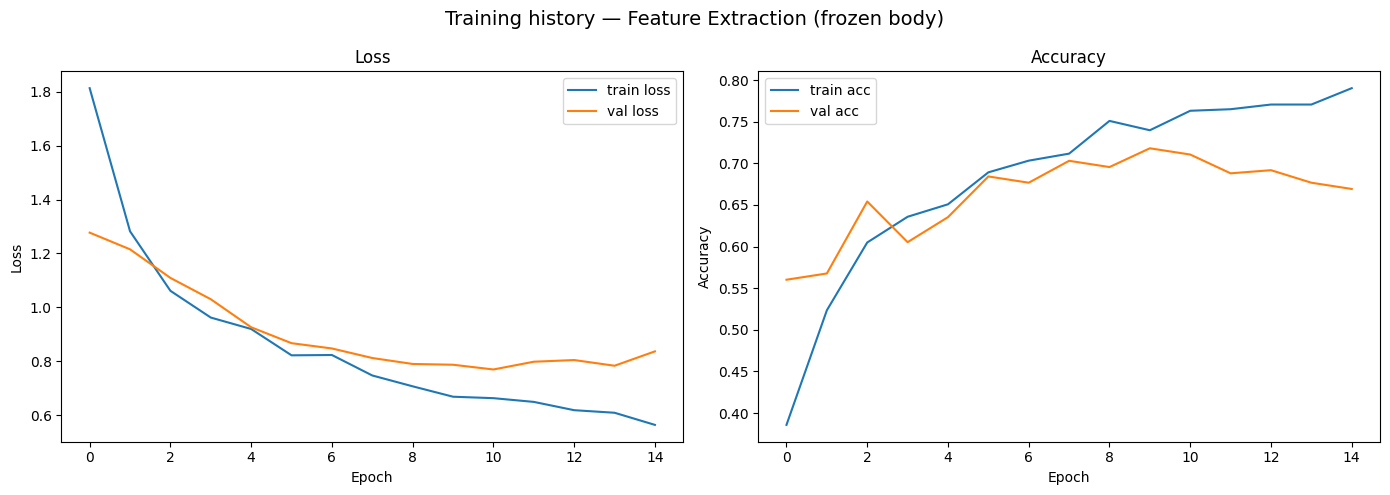

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"],     label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"],     label="train acc")
ax2.plot(history.history["val_accuracy"], label="val acc")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training history — Feature Extraction (frozen body)", fontsize=14)
plt.tight_layout()
plt.show()

## Step 7 — Evaluate on validation set

In [ ]:
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f"\nValidation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"\nValidation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6692 - loss: 0.8363

Validation accuracy: 0.6692 (66.92%)

Validation accuracy: 0.6692 (66.92%)


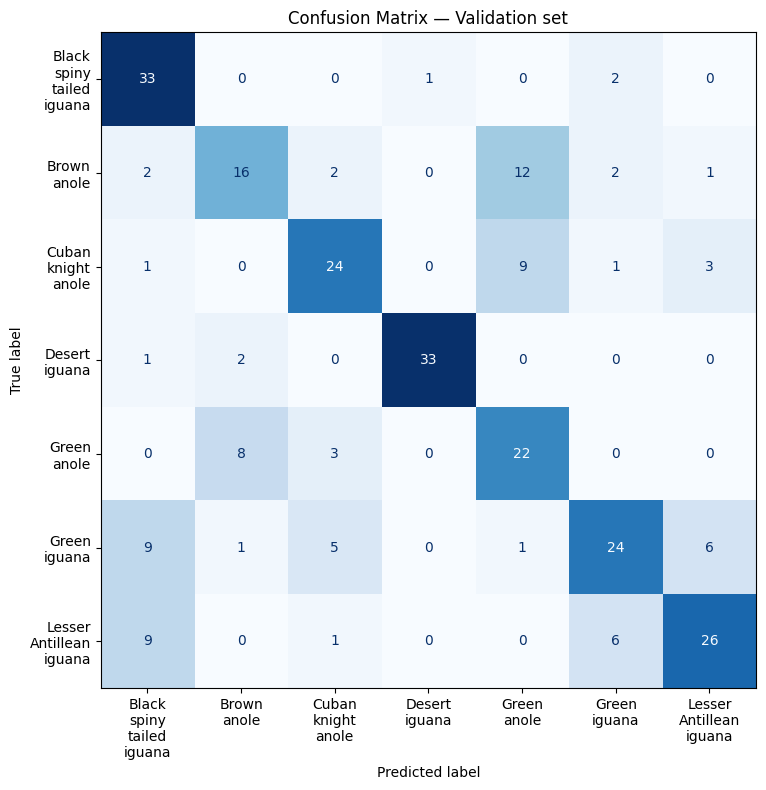

In [ ]:
# ── Confusion matrix ────────────────────────────────────────────────────────────
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[c.replace("_", "\n") for c in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Validation set")
plt.tight_layout()
plt.show()

## Step 8 — Generate submission file

Read the test images, predict, map class indices back to the numeric IDs from `Classes_nummering.xlsx`, and write `submission.csv`.

In [ ]:
# ── Load class numbering from xlsx ─────────────────────────────────────────────
# Inspect the columns printed in Step 2 and adjust the indices here if needed
classes_df = pd.read_excel(CLASSES_XLSX)

NAME_COL = classes_df.columns[0]   # column with the species name string
ID_COL   = classes_df.columns[1]   # column with the numeric id

name_to_id = dict(zip(classes_df[NAME_COL], classes_df[ID_COL]))
print("name -> id mapping:", name_to_id)

name -> id mapping: {0: 'Black_spiny_tailed_iguana', 1: 'Brown_anole', 2: 'Cuban_knight_anole', 3: 'Desert_iguana', 4: 'Green_anole', 5: 'Green_iguana', 6: 'Lesser_Antillean_iguana'}


In [ ]:
# ── Read test ids ───────────────────────────────────────────────────────────────
test_df   = pd.read_csv(TEST_CSV)
ID_COLUMN = test_df.columns[0]   # usually 'id' or 'ID'
test_ids  = test_df[ID_COLUMN].tolist()
print(f"{len(test_ids)} test images to predict")

326 test images to predict


In [ ]:
# ── Predict on test images ──────────────────────────────────────────────────────
predictions = []

for img_id in test_ids:
    for ext in [".jpg", ".jpeg", ".png"]:
        img_path = TEST_DIR / f"{img_id}{ext}"
        if img_path.exists():
            break

    img       = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = preprocess_input(img_array)             # same preprocessing as training
    img_array = tf.expand_dims(img_array, axis=0)

    pred       = model.predict(img_array, verbose=0)
    class_name = CLASS_NAMES[np.argmax(pred[0])]
    predictions.append(classes_df.loc[classes_df[ID_COL] == class_name, NAME_COL].iloc[0])

print(f"Done! {len(predictions)} predictions made.")
print("Sample:", predictions[:10])

Done! 326 predictions made.
Sample: [np.int64(0), np.int64(5), np.int64(2), np.int64(5), np.int64(0), np.int64(4), np.int64(6), np.int64(4), np.int64(4), np.int64(1)]


In [ ]:
# ── Write submission.csv ────────────────────────────────────────────────────────
submission_df = pd.DataFrame({ID_COLUMN: test_ids, "label": predictions})
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"Submission saved to: {SUBMISSION_PATH}")
print(submission_df.head(10))

Submission saved to: saved_models\submission.csv
   id  label
0   1      0
1   2      5
2   3      2
3   4      5
4   5      0
5   6      4
6   7      6
7   8      4
8   9      4
9  10      1


---
## Things to experiment with

Once the baseline is working, here are knobs you can turn to improve accuracy:

| What | Where | Try |
|------|-------|-----|
| **Base model** | Step 4 | Swap `EfficientNetV2S` -> `ResNet50V2`, `MobileNetV3Large`, `ConvNeXtBase` |
| **Image size** | Step 1 config | 224 -> 300 or 384 (bigger = more detail, more memory) |
| **Augmentation** | Step 3 | Add `RandomFlip("vertical")`, `RandomTranslation`, `RandomShear` |
| **Head architecture** | Step 4 | More/fewer Dense layers, different Dropout rates |
| **Epochs** | Step 1 config | Increase `EPOCHS` |
| **Fine-tuning** | After Step 5 | Set `base_model.trainable = True`, recompile with `lr=1e-5`, train again |
| **Class weights** | `model.fit()` | Add `class_weight=...` if classes are imbalanced |
| **Batch size** | Step 1 config | Smaller = noisier gradients (sometimes helps generalization) |

In [ ]:
# Validation F1 score (macro + weighted)
from pathlib import Path
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report

DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
MODEL_PATH = Path("saved_models") / "iguana_model.keras"

BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42

preprocess_input = tf.keras.applications.efficientnet_v2.preprocess_input

model = tf.keras.models.load_model(MODEL_PATH)
model_input_size = model.input_shape[1:3]

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=model_input_size,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

CLASS_NAMES = val_ds.class_names
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

val_f1_macro = f1_score(y_true, y_pred, average="macro")
val_f1_weighted = f1_score(y_true, y_pred, average="weighted")

print(f"Validation F1 (macro):    {val_f1_macro:.4f}")
print(f"Validation F1 (weighted): {val_f1_weighted:.4f}")
print("\nPer-class report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Validation F1 (macro):    0.6675
Validation F1 (weighted): 0.6662

Per-class report:
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana     0.6000    0.9167    0.7253        36
              Brown_anole     0.5926    0.4571    0.5161        35
       Cuban_knight_anole     0.6857    0.6316    0.6575        38
            Desert_iguana     0.9706    0.9167    0.9429        36
              Green_anole     0.5000    0.6667    0.5714        33
             Green_iguana     0.6857    0.5217    0.5926        46
  Lesser_Antillean_iguana     0.7222    0.6190    0.6667        42

                 accuracy                         0.6692       266
                macro avg     0.6795    0.6756    0.6675       266
             weighted avg     0.6831    0.6692    0.6662       266

